# Student Performance Prediction

## Objective
Predict a student's academic performance category (Fail / Average / Good / Excellent)
based on study habits, attendance, parental involvement, and other academic/behavioral factors.

## Goals
1. Load and explore the Student Performance Factors dataset
2. Clean the data and engineer a classification target from Exam_Score
3. Perform feature selection to identify the strongest predictors
4. Train and compare two classification models: Logistic Regression and Random Forest
5. Evaluate models using accuracy, precision, recall, and confusion matrices
6. Save the trained model for deployment (Streamlit app)

## Dataset
StudentPerformanceFactors.csv — 6,607 rows, 20 columns
Source: Kaggle - Student Performance Factors

## Step 1: Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os


In [18]:

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap


## Step 2: Load Dataset & Basic Dataset Information

In [19]:
df = pd.read_csv(r"../data/StudentPerformanceFactors.csv")

# Quick sanity checks before doing anything else
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

# ==========================================================
# Initial Data Overview
# ==========================================================
print("Data types:\n")
print(df.dtypes)

print("\nSummary statistics (numeric columns):")
df.describe()

Shape of dataset: (6607, 20)

Column names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']
Data types:

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              in

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


#### Missing Values/Duplicates

In [20]:
print("\nMissing values per column:\n")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")


Missing values per column:

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Duplicate rows: 0


## Step 3: Data Cleaning & Exploratory Data Analysis

#### Clean the data

In [21]:
# Fill missing values with mode, remove duplicates
for col in df.columns[df.isnull().any()]:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()

print("Missing values left:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)


# ==========================================================
#Remove Duplicate Rows
# ==========================================================
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f"Removed {before - after} duplicate rows")
print(f"Dataset shape after cleaning: {df.shape}")

Missing values left: 0
Shape after cleaning: (6607, 20)
Removed 0 duplicate rows
Dataset shape after cleaning: (6607, 20)


#### Separate column types

In [22]:
# ==========================================================
# Identify Numeric vs Categorical Columns
# ==========================================================
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


#### Target variable distribution (Exam_Score)

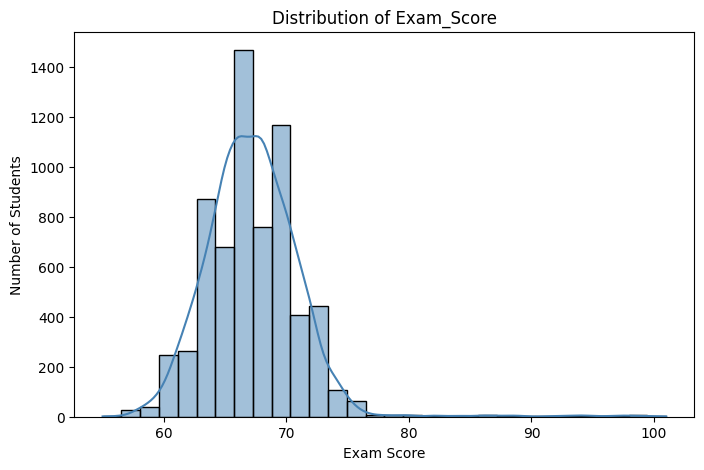

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


In [23]:
# ==========================================================
# Explore Exam_Score (our raw target)
# ==========================================================
plt.figure(figsize=(8, 5))
sns.histplot(df["Exam_Score"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Exam_Score")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

print(df["Exam_Score"].describe())

####  Correlation heatmap (numeric features vs Exam_Score)

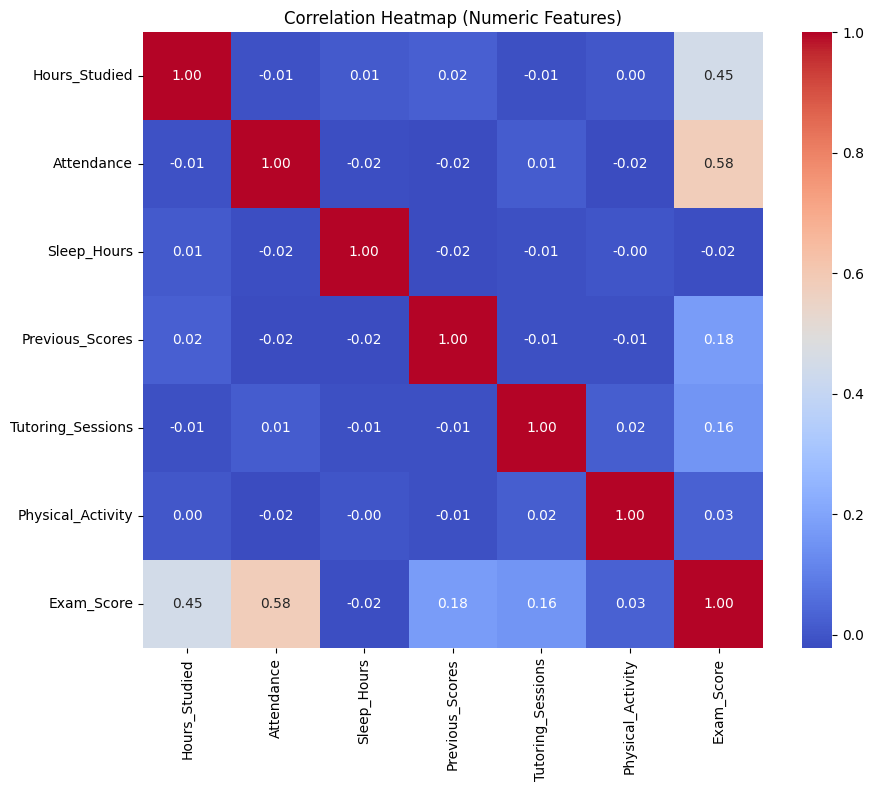

Correlation with Exam_Score:

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [24]:
# ==========================================================
# Correlation Between Numeric Features
# ==========================================================
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Which numeric features correlate most with Exam_Score?
print("Correlation with Exam_Score:\n")
print(corr["Exam_Score"].sort_values(ascending=False))

#### Key relationships (Hours_Studied & Attendance vs Exam_Score)

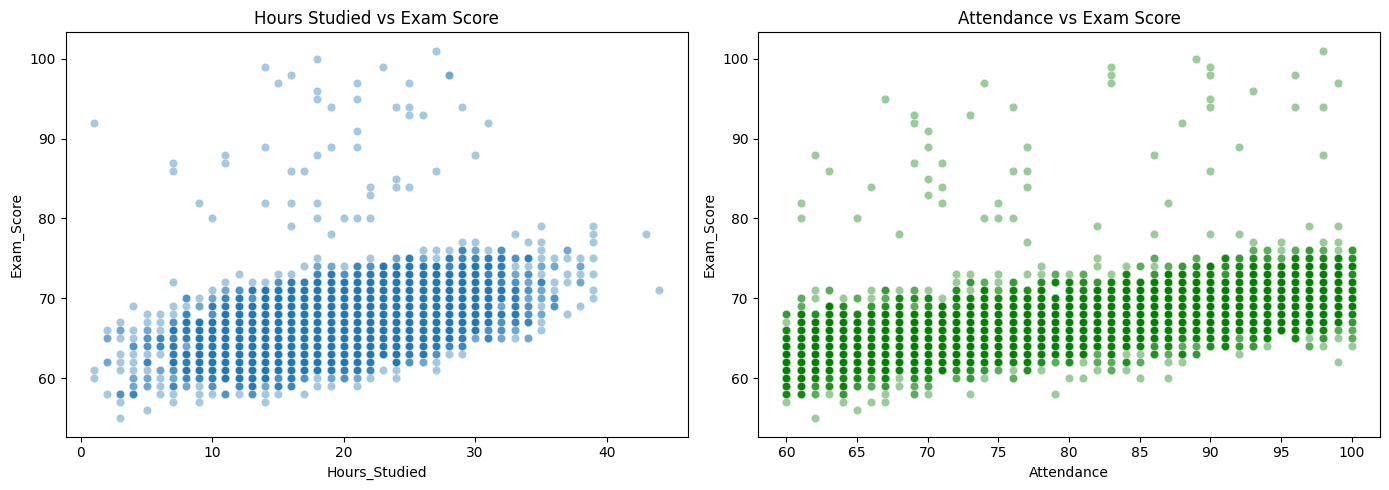

In [25]:
# ==========================================================
# Visualize Key Relationships
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score", ax=axes[0], alpha=0.4)
axes[0].set_title("Hours Studied vs Exam Score")

sns.scatterplot(data=df, x="Attendance", y="Exam_Score", ax=axes[1], alpha=0.4, color="green")
axes[1].set_title("Attendance vs Exam Score")

plt.tight_layout()
plt.show()

#### Categorical feature impact on Exam_Score

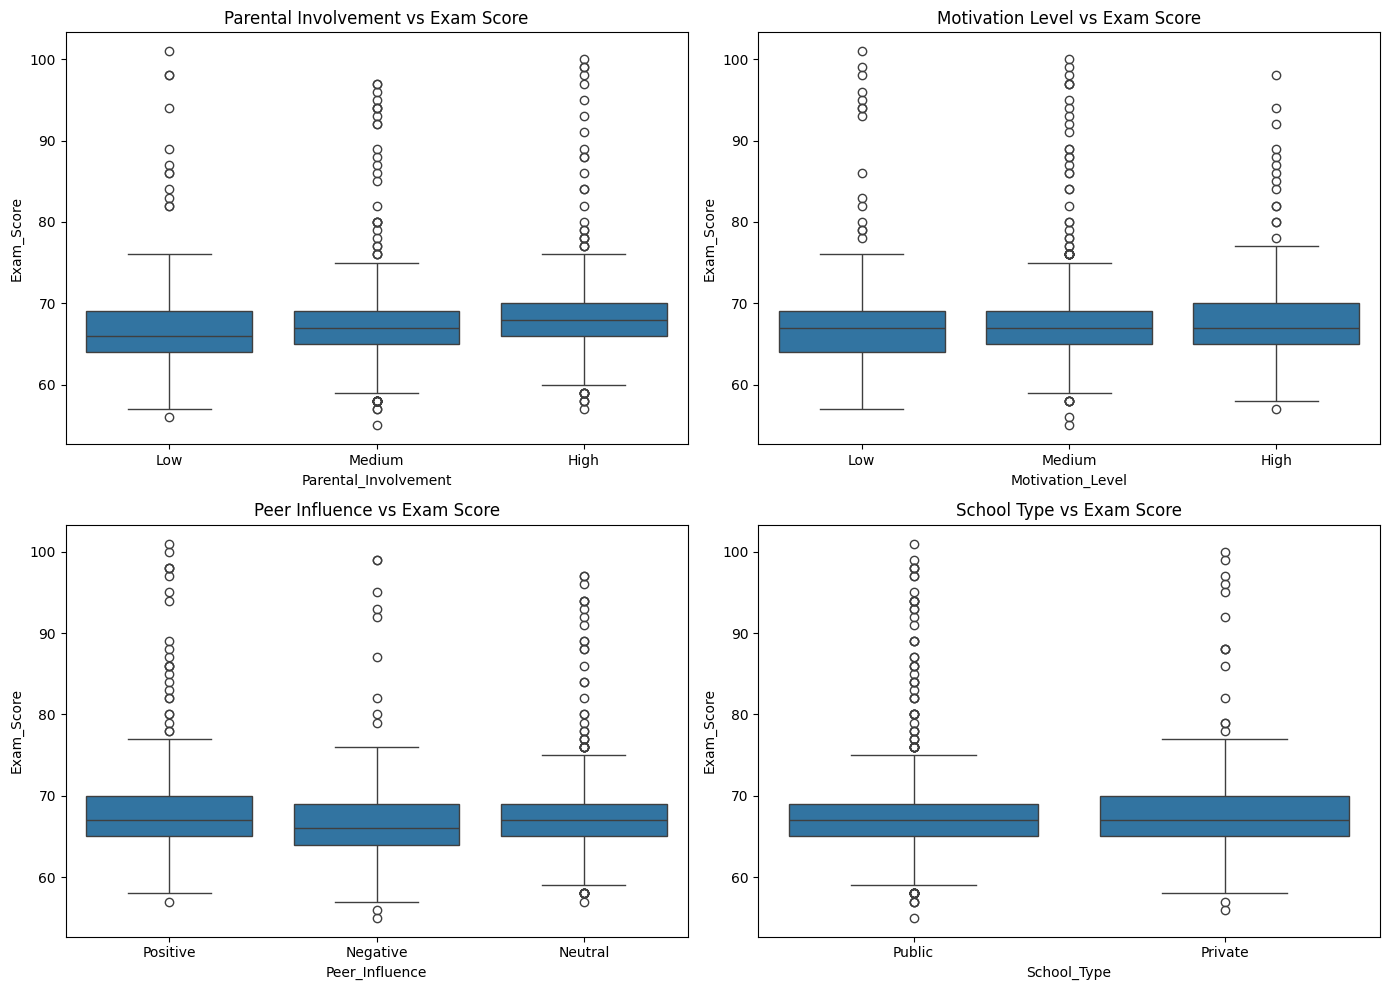

In [26]:
# ==========================================================
# Categorical Features vs Exam_Score
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x="Parental_Involvement", y="Exam_Score", ax=axes[0, 0])
axes[0, 0].set_title("Parental Involvement vs Exam Score")

sns.boxplot(data=df, x="Motivation_Level", y="Exam_Score", ax=axes[0, 1])
axes[0, 1].set_title("Motivation Level vs Exam Score")

sns.boxplot(data=df, x="Peer_Influence", y="Exam_Score", ax=axes[1, 0])
axes[1, 0].set_title("Peer Influence vs Exam Score")

sns.boxplot(data=df, x="School_Type", y="Exam_Score", ax=axes[1, 1])
axes[1, 1].set_title("School Type vs Exam Score")

plt.tight_layout()
plt.show()

## Step 4 Creating the Classification Target

#### Creating the Classification Target

`Exam_Score` is a continuous number, but this project requires classification
models (Logistic Regression, Random Forest). So we bin `Exam_Score` into
four performance categories: **Fail, Average, Good, Excellent**.

| Class     | Score Range |
|-----------|-------------|
| Fail      | 0 – 60      |
| Average   | 60 – 70     |
| Good      | 70 – 80     |
| Excellent | 80 – 101    |

The original `Exam_Score` column is dropped after binning so it can't
leak directly into the model (it would trivially reveal the answer).

Performance_Class
Average      5379
Good         1040
Fail          145
Excellent      43
Name: count, dtype: int64


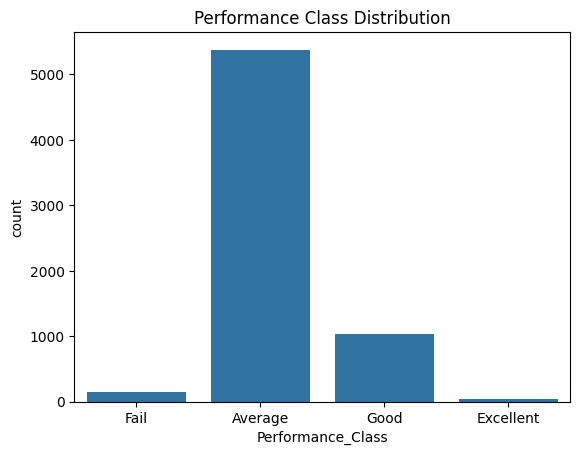

In [27]:
# Bin Exam_Score into performance classes
bins = [0, 60, 70, 80, 101]
labels = ["Fail", "Average", "Good", "Excellent"]

df["Performance_Class"] = pd.cut(df["Exam_Score"], bins=bins, labels=labels, include_lowest=True)

# Drop the raw score so it can't leak into the model
df = df.drop(columns=["Exam_Score"])

# Check class distribution
print(df["Performance_Class"].value_counts())
sns.countplot(data=df, x="Performance_Class", order=labels)
plt.title("Performance Class Distribution")
plt.show()

## Step 5: Feature Engineering


#### Feature Engineering

Create new features that combine existing signals in ways that might be
more predictive than any single raw column:

- **Study_Efficiency** — study hours relative to sleep (studying a lot on
  little sleep is a different story than studying a lot with good rest)
- **Support_Score** — combines Parental_Involvement, Access_to_Resources,
  Family_Income, and Teacher_Quality into one numeric "support level"
- **Engagement_Score** — combines Tutoring_Sessions and Extracurricular
  participation into one "engagement" measure
- **Attendance_x_Previous** — interaction between attendance and
  historical performance, since consistently-attending strong students
  behave differently than inconsistent ones


In [28]:
# Map ordinal Low/Medium/High-style columns to numbers so we can combine them
ordinal_map = {"Low": 1, "Medium": 2, "High": 3}

support_cols = ["Parental_Involvement", "Access_to_Resources",
                 "Family_Income", "Teacher_Quality"]

support_numeric = df[support_cols].apply(lambda col: col.map(ordinal_map))
df["Support_Score"] = support_numeric.sum(axis=1)

# Study efficiency: studying a lot on little sleep is weighted differently
df["Study_Efficiency"] = df["Hours_Studied"] / (df["Sleep_Hours"] + 1)

# Engagement: tutoring + extracurricular participation combined
extracurricular_numeric = df["Extracurricular_Activities"].map({"No": 0, "Yes": 1})
df["Engagement_Score"] = df["Tutoring_Sessions"] + (extracurricular_numeric * 2)

# Interaction term: attendance matters more/less depending on past performance
df["Attendance_x_Previous"] = df["Attendance"] * df["Previous_Scores"] / 100

print("New features added:", ["Support_Score", "Study_Efficiency", "Engagement_Score", "Attendance_x_Previous"])
df[["Support_Score", "Study_Efficiency", "Engagement_Score", "Attendance_x_Previous"]].describe()

New features added: ['Support_Score', 'Study_Efficiency', 'Engagement_Score', 'Attendance_x_Previous']


,Support_Score,Study_Efficiency,Engagement_Score,Attendance_x_Previous
count,6607.000000,6607.000000,6607.000000,6607.000000
mean,8.169517,2.577849,2.685788,60.005935
std,1.363429,0.936921,1.576474,14.361045
min,4.000000,0.111111,0.000000,30.000000
25%,7.000000,1.909091,2.000000,49.280000
50%,8.000000,2.500000,3.000000,58.800000
75%,9.000000,3.125000,4.000000,69.840000
max,12.000000,7.600000,10.000000,100.000000


## Step 6: Encoding Categorical Variables

#### Encoding Categorical Variables

Machine learning models need numbers, not text labels. We convert each
categorical column (Gender, Parental_Involvement, School_Type, etc.)
into numeric codes using Label Encoding.

In [29]:
categorical_cols = df.select_dtypes(include="object").columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print("Encoded columns:", list(categorical_cols))
df.head()

Encoded columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Performance_Class,Support_Score,Study_Efficiency,Engagement_Score,Attendance_x_Previous
0,23,84,1,0,0,7,73,1,1,0,...,3,0,1,2,1,Average,7,2.875000,0,61.32
1,19,64,1,2,0,8,59,1,1,2,...,4,0,0,1,0,Average,7,2.111111,2,37.76
2,24,98,2,2,1,7,91,2,1,2,...,4,0,2,2,1,Good,8,3.000000,4,89.18
3,29,89,1,2,1,8,98,2,1,1,...,4,0,1,1,1,Good,7,3.222222,3,87.22
4,19,92,2,2,1,6,65,2,1,3,...,4,0,0,2,0,Average,9,2.714286,5,59.80


## Step 7: Feature Scaling

#### Feature Scaling

Numeric columns (Hours_Studied, Attendance, Sleep_Hours, etc.) are on
different scales. Logistic Regression is sensitive to this, so we
standardize numeric features to mean 0, standard deviation 1.

In [30]:
numeric_cols = ["Hours_Studied", "Attendance", "Sleep_Hours",
                 "Previous_Scores", "Tutoring_Sessions", "Physical_Activity",
                 "Support_Score", "Study_Efficiency", "Engagement_Score", "Attendance_x_Previous"]

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df[numeric_cols].describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Support_Score,Study_Efficiency,Engagement_Score,Attendance_x_Previous
count,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03
mean,-1.161474e-16,-3.089199e-16,-2.016449e-16,2.048712e-16,7.850707e-17,-1.720703e-17,2.946704e-16,4.409301e-17,-4.839477e-17,3.441406e-16
std,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00
min,-3.167760e+00,-1.730158e+00,-2.063380e+00,-1.741167e+00,-1.213934e+00,-2.877953e+00,-3.058343e+00,-2.633012e+00,-1.703797e+00,-2.089556e+00
25%,-6.636453e-01,-8.641026e-01,-7.009903e-01,-8.383073e-01,-4.012417e-01,-9.383768e-01,-8.578416e-01,-7.138364e-01,-4.350466e-01,-7.469335e-01
50%,4.118568e-03,1.953115e-03,-1.979558e-02,-4.898448e-03,-4.012417e-01,3.141133e-02,-1.243410e-01,-8.309616e-02,1.993284e-01,-8.397898e-02
75%,6.718825e-01,8.680088e-01,6.613991e-01,8.979612e-01,4.114511e-01,1.001199e+00,6.091597e-01,5.840329e-01,8.337034e-01,6.848255e-01
max,4.010702e+00,1.734065e+00,2.023788e+00,1.731370e+00,5.287608e+00,2.940776e+00,2.809661e+00,5.360677e+00,4.639953e+00,2.785110e+00


## Step 8: Feature Selection

#### Feature Selection

Not all 19 features contribute equally to predicting performance. We use
a Random Forest's built-in feature importance to rank features, then
keep only the top 10 most predictive ones. This reduces noise and
speeds up training.

Attendance                    0.190025
Attendance_x_Previous         0.148747
Hours_Studied                 0.145405
Study_Efficiency              0.096419
Previous_Scores               0.059122
Support_Score                 0.056558
Engagement_Score              0.035050
Sleep_Hours                   0.029504
Tutoring_Sessions             0.028848
Physical_Activity             0.026307
Peer_Influence                0.020798
Access_to_Resources           0.020702
Parental_Education_Level      0.019226
Parental_Involvement          0.019013
Distance_from_Home            0.016582
Motivation_Level              0.016567
Family_Income                 0.014856
Teacher_Quality               0.012556
Gender                        0.009702
Extracurricular_Activities    0.009160
School_Type                   0.009016
Learning_Disabilities         0.007989
Internet_Access               0.007849
dtype: float64


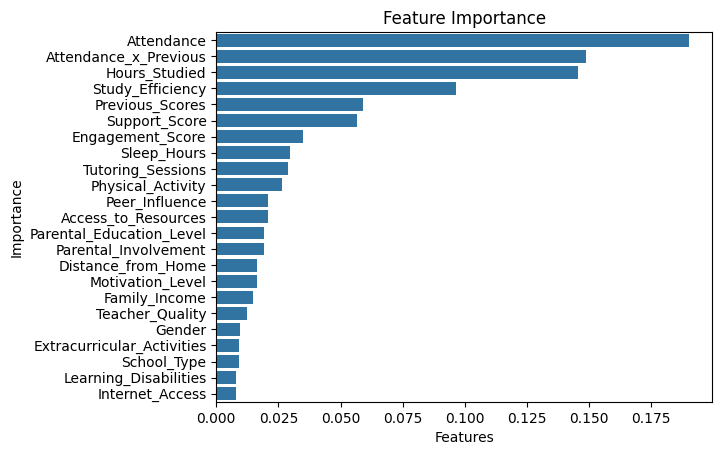


Selected features: ['Attendance', 'Attendance_x_Previous', 'Hours_Studied', 'Study_Efficiency', 'Previous_Scores', 'Support_Score', 'Engagement_Score', 'Sleep_Hours', 'Tutoring_Sessions', 'Physical_Activity']


In [31]:
X = df.drop(columns=["Performance_Class"])
y = df["Performance_Class"]

# Quick Random Forest just to rank feature importance
ranker = RandomForestClassifier(n_estimators=200, random_state=42)
ranker.fit(X, y)

importance = pd.Series(ranker.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance)

sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Keep top 10 features
top_features = importance.head(10).index.tolist()
X = X[top_features]
print("\nSelected features:", top_features)

## Step 9: Train-Test Split

#### Train-Test Split

Split the data into training (80%) and testing (20%) sets. We stratify
by the target so each class is represented proportionally in both sets
— important given the class imbalance we saw earlier.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5285, 10)
Test size: (1322, 10)


## Step 10: Handling Class Imbalance with SMOTE


#### Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic
examples of the minority classes (Fail, Excellent) so the model sees a
more balanced dataset during training.

**Important:** SMOTE is applied ONLY to the training set, never the test
set — the test set must reflect real-world class distribution so
evaluation stays honest.


In [33]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_resampled.value_counts().to_dict())


Before SMOTE: {'Average': 4303, 'Good': 832, 'Fail': 116, 'Excellent': 34}
After SMOTE: {'Fail': 4303, 'Average': 4303, 'Good': 4303, 'Excellent': 4303}


## Step 11: Model Training

#### Model Training

Train multiple classification models on the same dataset to compare their performance and identify the best model for predicting student performance.

- **Logistic Regression** — A simple, fast linear classification algorithm that serves as a strong baseline for binary and multi-class classification problems.

- **Random Forest Classifier** — An ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It performs well on complex, non-linear data and provides feature importance scores.

- **Support Vector Machine (SVM)** — A powerful classification algorithm that finds the optimal decision boundary (hyperplane) to separate different classes. It is particularly effective for high-dimensional datasets and can handle non-linear relationships using kernel functions.

- **Neural Network (MLP Classifier)** — A machine learning model inspired by the human brain that consists of interconnected layers of neurons. It learns complex patterns in data and is well-suited for capturing non-linear relationships between features.

- **XGBoost Classifier** — An advanced gradient boosting algorithm that builds decision trees sequentially, with each tree correcting the errors of the previous one. It is known for its high accuracy, efficiency, and excellent performance on structured/tabular datasets.

In [34]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000, solver="saga", tol=1e-3, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42, class_weight="balanced"),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, early_stopping=True, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric="mlogloss"
    ),
}

# Both XGBoost and Neural Network need numeric labels (not strings) to train reliably
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train_resampled)

# Models that require numeric labels instead of string labels
needs_encoded_target = {"XGBoost", "Neural Network"}

trained_models = {}
for name, model in models.items():
    y_target = y_train_encoded if name in needs_encoded_target else y_train_resampled
    model.fit(X_train_resampled, y_target)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: SVM
Trained: Neural Network
Trained: XGBoost


## Step 12: Model Evaluation

#### Model Evaluation

Evaluate all models on the unseen test set using accuracy and a
per-class classification report (precision, recall, F1). Given the
class imbalance from Step 4, accuracy alone can be misleading — the
per-class scores matter more here.


Logistic Regression — Accuracy: 0.6498
              precision    recall  f1-score   support

     Average       0.99      0.60      0.74      1076
   Excellent       0.01      0.44      0.02         9
        Fail       0.38      0.83      0.52        29
        Good       0.70      0.90      0.79       208

    accuracy                           0.65      1322
   macro avg       0.52      0.69      0.52      1322
weighted avg       0.92      0.65      0.74      1322



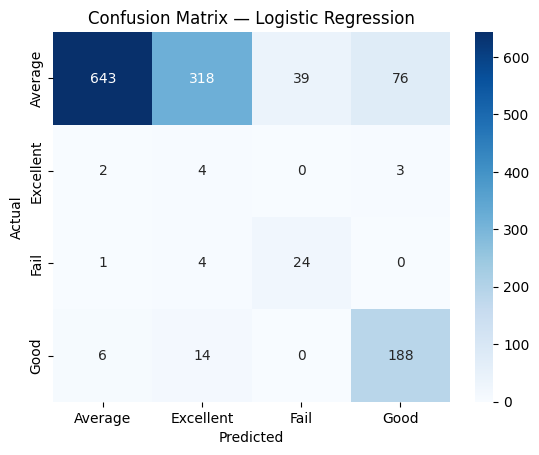


Random Forest — Accuracy: 0.8941
              precision    recall  f1-score   support

     Average       0.94      0.93      0.94      1076
   Excellent       0.00      0.00      0.00         9
        Fail       0.55      0.55      0.55        29
        Good       0.73      0.79      0.76       208

    accuracy                           0.89      1322
   macro avg       0.56      0.57      0.56      1322
weighted avg       0.89      0.89      0.89      1322



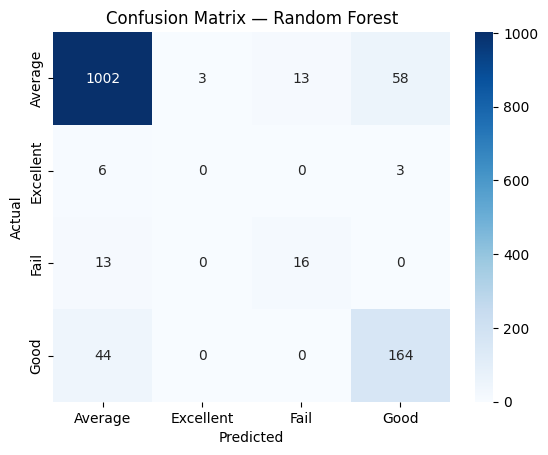


SVM — Accuracy: 0.8502
              precision    recall  f1-score   support

     Average       0.97      0.85      0.91      1076
   Excellent       0.02      0.11      0.03         9
        Fail       0.37      0.79      0.51        29
        Good       0.70      0.88      0.78       208

    accuracy                           0.85      1322
   macro avg       0.52      0.66      0.56      1322
weighted avg       0.91      0.85      0.87      1322



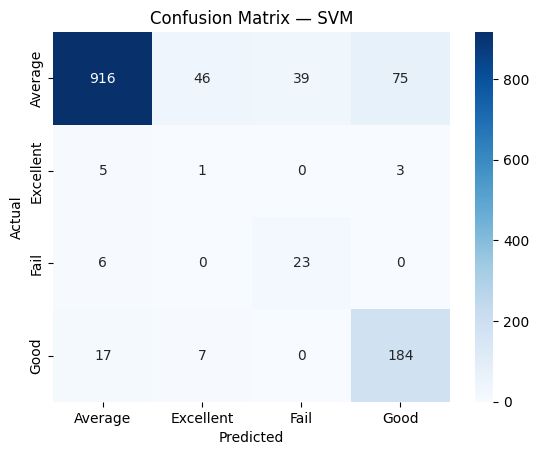


Neural Network — Accuracy: 0.8903
              precision    recall  f1-score   support

     Average       0.97      0.90      0.93      1076
   Excellent       0.00      0.00      0.00         9
        Fail       0.47      0.72      0.57        29
        Good       0.72      0.89      0.80       208

    accuracy                           0.89      1322
   macro avg       0.54      0.63      0.58      1322
weighted avg       0.91      0.89      0.90      1322



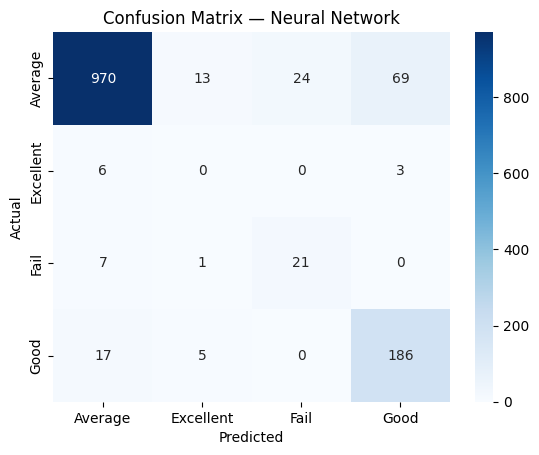


XGBoost — Accuracy: 0.9138
              precision    recall  f1-score   support

     Average       0.94      0.96      0.95      1076
   Excellent       0.00      0.00      0.00         9
        Fail       0.73      0.55      0.63        29
        Good       0.80      0.78      0.79       208

    accuracy                           0.91      1322
   macro avg       0.62      0.57      0.59      1322
weighted avg       0.91      0.91      0.91      1322



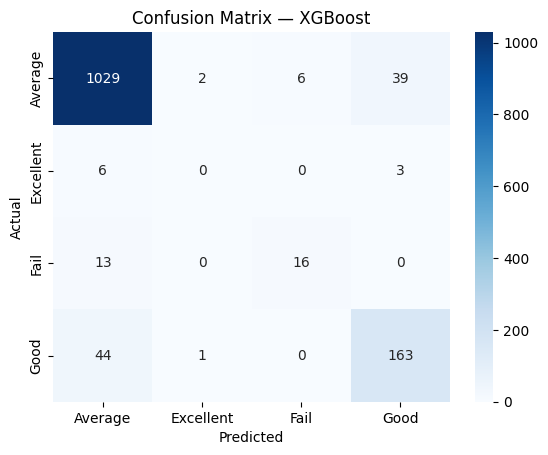

                 Model  Accuracy
4              XGBoost  0.913767
1        Random Forest  0.894100
3       Neural Network  0.890318
2                  SVM  0.850227
0  Logistic Regression  0.649773


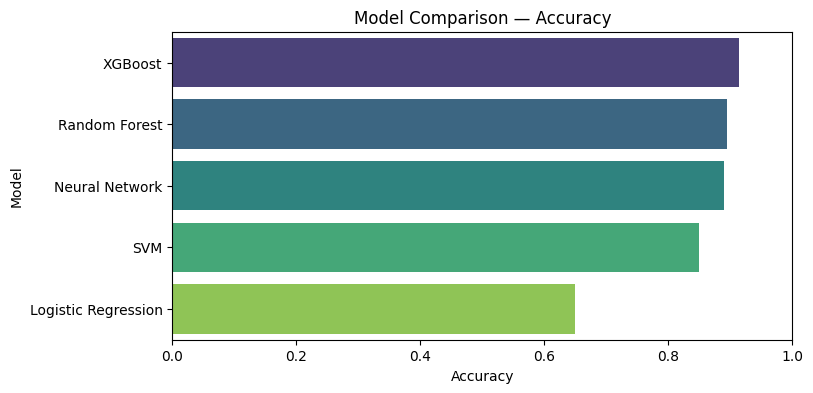

In [35]:
results = []

needs_decoding = {"XGBoost", "Neural Network"}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    if name in needs_decoding:
        y_pred = target_encoder.inverse_transform(y_pred)

    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

    print(f"\n{'='*50}\n{name} — Accuracy: {acc:.4f}\n{'='*50}")
    print(classification_report(y_test, y_pred, zero_division=0))

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Summary comparison table
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison — Accuracy")
plt.xlim(0, 1)
plt.show()

## Step 13: Explainability with SHAP


#### Explainability with SHAP

SHAP (SHapley Additive exPlanations) shows *why* a model made a specific
prediction — which features pushed it toward "Fail" vs "Excellent," and
by how much. We explain the Random Forest model here since tree-based
models work fastest with SHAP.


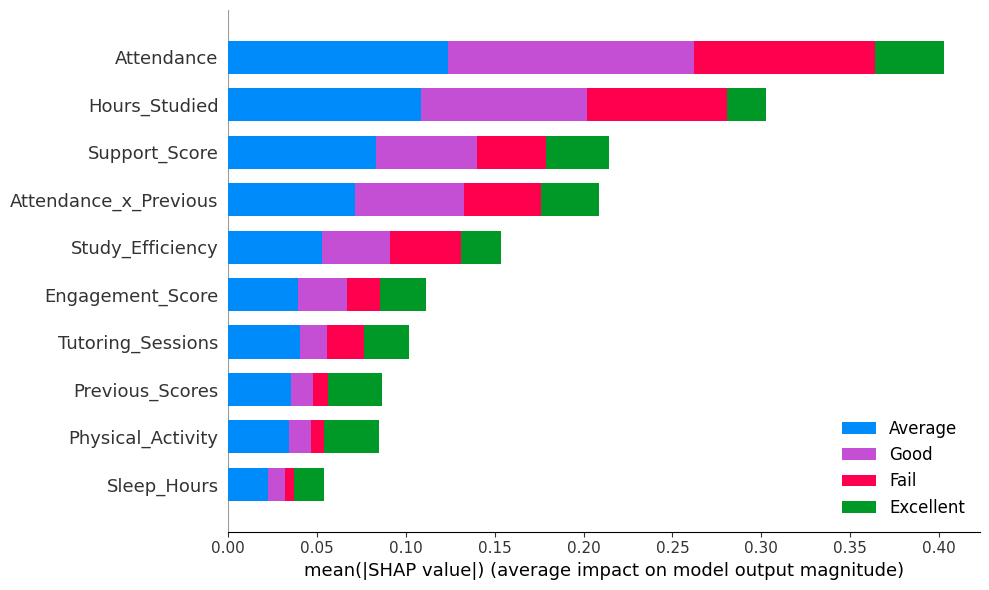

In [144]:
# TreeExplainer is fast and exact for tree-based models like Random Forest
explainer = shap.TreeExplainer(trained_models["Random Forest"])
shap_values = explainer.shap_values(X_test)

# Global feature importance — which features matter most overall
shap.summary_plot(
    shap_values, X_test, plot_type="bar",
    class_names=trained_models["Random Forest"].classes_,
    plot_size=(10, 6),
)

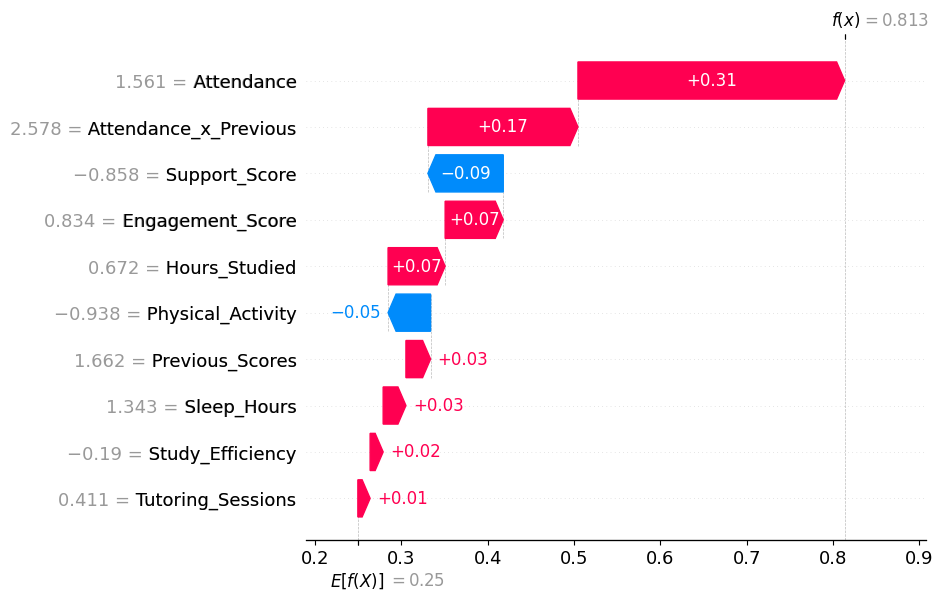

In [145]:
# Explain a single student's prediction (row 0 of the test set) — waterfall version
sample_idx = 0
rf_model = trained_models["Random Forest"]
predicted_class_idx = list(rf_model.classes_).index(
    rf_model.predict(X_test.iloc[[sample_idx]])[0]
)

if isinstance(shap_values, list):
    sample_shap_values = shap_values[predicted_class_idx][sample_idx]
else:
    sample_shap_values = shap_values[sample_idx, :, predicted_class_idx]

base_value = explainer.expected_value[predicted_class_idx]

explanation = shap.Explanation(
    values=sample_shap_values,
    base_values=base_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=X_test.columns.tolist(),
)

shap.plots.waterfall(explanation)

## Step 14: Saving the Model

#### Saving the Model

Save the trained models, along with the scaler, encoders, and the list
of selected features, into the `models/` folder. These are the exact
same objects the Streamlit app will load later to make predictions —
saving them here means we never have to retrain to deploy.

In [146]:
# Make sure the models folder exists (it should already, per your structure)
os.makedirs("../models", exist_ok=True)

for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_") + ".pkl"
    joblib.dump(model, f"../models/{filename}")
    print(f"Saved: {filename}")

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(encoders, "../models/encoders.pkl")
joblib.dump(target_encoder, "../models/target_encoder.pkl")   # needed for XGBoost predictions
joblib.dump(top_features, "../models/selected_features.pkl")

print("\nAll models and preprocessing objects saved to ../models/")


Saved: logistic_regression.pkl
Saved: random_forest.pkl
Saved: svm.pkl
Saved: neural_network.pkl
Saved: xgboost.pkl

All models and preprocessing objects saved to ../models/
